In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = pd.read_csv("all_tickets_processed_improved_v3.csv")

print(data.columns)
data.head()

Index(['Document', 'Topic_group'], dtype='object')


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.strip()
    return text

data['clean_text'] = data['Document'].apply(clean_text)

In [4]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    stop_words='english'
)

X = vectorizer.fit_transform(data['clean_text'])
y = data['Topic_group']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = LinearSVC()
model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [7]:
y_pred = model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8490802675585284

Classification Report:
                        precision    recall  f1-score   support

               Access       0.90      0.88      0.89      1455
Administrative rights       0.82      0.74      0.78       342
           HR Support       0.84      0.84      0.84      2107
             Hardware       0.82      0.86      0.84      2760
     Internal Project       0.89      0.83      0.86       451
        Miscellaneous       0.81      0.82      0.81      1400
             Purchase       0.95      0.90      0.92       497
              Storage       0.92      0.86      0.89       556

             accuracy                           0.85      9568
            macro avg       0.87      0.84      0.85      9568
         weighted avg       0.85      0.85      0.85      9568



In [9]:
def assign_priority(text):
    text = str(text).lower()
    
    if any(word in text for word in ["urgent", "asap", "immediately", "critical", "failure"]):
        return "High"
    elif any(word in text for word in ["delay", "slow", "issue"]):
        return "Medium"
    else:
        return "Low"

data['Priority'] = data['Document'].apply(assign_priority)

print(data[['Document','Priority']].head())

                                            Document Priority
0  connection with icon icon dear please setup ic...      Low
1  work experience user work experience user hi w...      Low
2  requesting for meeting requesting meeting hi p...      Low
3  reset passwords for external accounts re expir...   Medium
4  mail verification warning hi has got attached ...      Low


In [10]:
sample = ["System failure, need urgent help"]

sample_clean = [clean_text(s) for s in sample]
sample_vec = vectorizer.transform(sample_clean)

predicted_category = model.predict(sample_vec)

print("Predicted Category:", predicted_category[0])
print("Predicted Priority:", assign_priority(sample[0]))

Predicted Category: Hardware
Predicted Priority: High


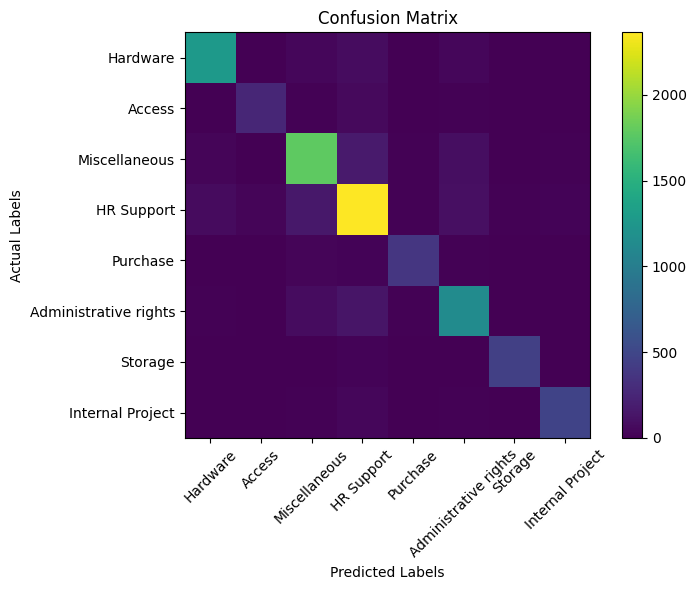

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it
plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

plt.colorbar()

# Show labels (optional but better)
labels = y.unique()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

plt.tight_layout()
plt.show()